In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('sales_electroprima1.csv')
df.head()

,transaction_id,date,branch,product_category,product_name,unit_price,quantity_sold,total_sales,payment_method,customer_gender,customer_age,satisfaction_rating,promo_status,daily_ad_spend
0,TRX01409,2026-01-01,Surabaya,Laptop,Laptop A14,14493000,1,14493000,E-Wallet,M,57.0,NaN,Regular,584000
1,TRX00846,2026-01-01,Bandung,Smartphone,Smartphone MaxEdge,7967000,5,39835000,Credit Card,M,21.0,NaN,Regular,1652000
2,TRX01550,2026-01-01,Jakarta,Accessories,Wireless Mouse,126000,4,504000,Cash,F,33.0,5.0,Regular,1092000
3,TRX01622,2026-01-01,Jakarta,Laptop,Laptop X1,13021000,3,39063000,Credit Card,F,39.0,1.0,Regular,727000
4,TRX01996,2026-01-01,Malang,Smartphone,Smartphone NovaLite,5472000,2,10944000,Credit Card,F,41.0,4.0,Regular,1630000


In [3]:
mean_rating = df['satisfaction_rating'].mean()
median_rating = df['satisfaction_rating'].median()
mode_rating = df['satisfaction_rating'].mode()[0]

print('Mean  :', mean_rating)
print('Median:', median_rating)
print('Mode  :', mode_rating)


Mean  : 3.986166007905138
Median: 4.0
Mode  : 4.0


In [ ]:
mean_ts = df['total_sales'].mean()
median_ts = df['total_sales'].median()

print('Mean total_sales  :', mean_ts)
print('Median total_sales:', median_ts)


Mean total_sales  : 14873672.727272727
Median total_sales: 10801000.0


In [5]:
variability = df.groupby('product_category')['unit_price']\
    .agg(['mean', 'std', 'var'])
print(variability)

                          mean           std           var
product_category                                          
Accessories       2.714015e+05  1.299694e+05  1.689206e+10
Home Appliances   3.178965e+06  1.553542e+06  2.413494e+12
Laptop            1.002573e+07  2.886556e+06  8.332207e+12
Smartphone        4.871319e+06  1.917567e+06  3.677063e+12


In [6]:
laptop = df[df['product_category'] == 'Laptop']['unit_price']

q1 = laptop.quantile(0.25)
q3 = laptop.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print('Q1 :', q1)
print('Q3 :', q3)
print('IQR:', iqr)
print('Outlier bounds:', lower_bound, '-', upper_bound)

Q1 : 7476000.0
Q3 : 12511000.0
IQR: 5035000.0
Outlier bounds: -76500.0 - 20063500.0


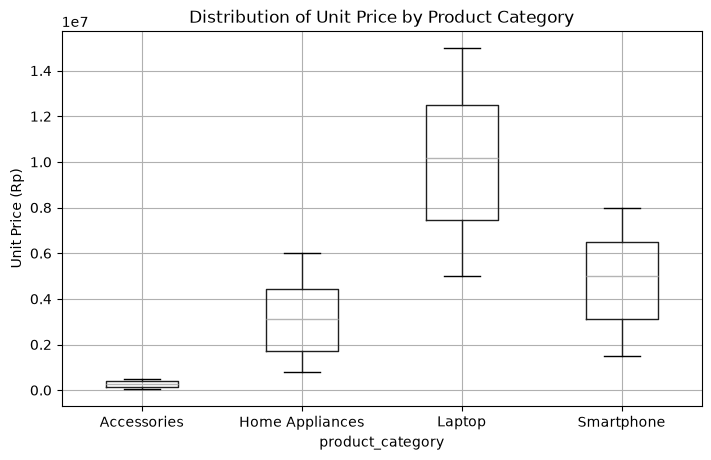

In [7]:
df.boxplot(column='unit_price', by='product_category', figsize=(8,5))
plt.title('Distribution of Unit Price by Product Category')
plt.suptitle('')
plt.ylabel('Unit Price (Rp)')
plt.show()

In [9]:
df_surabaya = df[df['branch']=='Surabaya']
mean_ts = df['total_sales'].mean()
median_ts = df['total_sales'].median()

print('Mean total_sales  :', mean_ts)
print('Median total_sales:', median_ts)


Mean total_sales  : 14873672.727272727
Median total_sales: 10801000.0


In [10]:
df_smartphone = df[df['product_category'] == 'Smartphone']
variability = df_smartphone.groupby('product_category')['unit_price']\
    .agg(['mean', 'std', 'var'])
print(variability)

                          mean           std           var
product_category                                          
Smartphone        4.871319e+06  1.917567e+06  3.677063e+12


In [11]:
df_laptop = df[df['product_category'] == 'Laptop']
variability = df_laptop.groupby('product_category')['unit_price']\
    .agg(['mean', 'std', 'var'])
print(variability)

                          mean           std           var
product_category                                          
Laptop            1.002573e+07  2.886556e+06  8.332207e+12


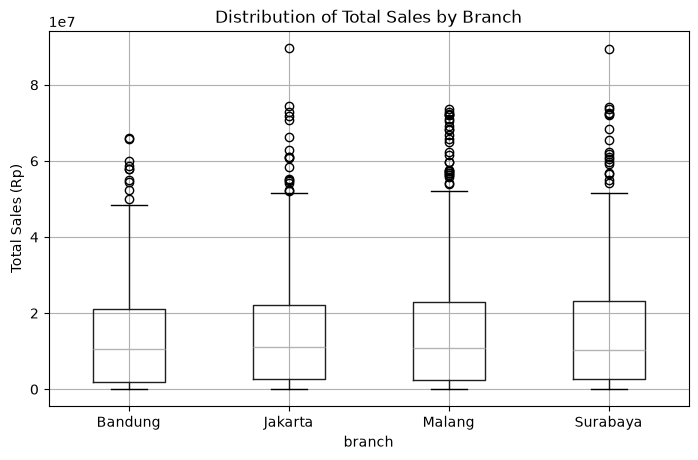

In [13]:
df.boxplot(column='total_sales', by='branch', figsize=(8,5))
plt.title('Distribution of Total Sales by Branch')
plt.suptitle('')
plt.ylabel('Total Sales (Rp)')
plt.show()